
# CHƯƠNG 7 — CODE CHO TẤT CẢ CÁC VÍ DỤ

Notebook này được xây dựng theo **Chương 7: Phương trình vi phân**.

Phạm vi:
- Ghi lại chi tiết đề bài của mọi ví dụ đang hoạt động trong nội dung chương.
- Viết code cho các phương pháp đúng theo công thức được trình bày trong chương.
- Không đưa các phần nằm trong môi trường `comment`.
- Không giải phần bài tập cuối chương.

Các ví dụ được triển khai:

1. Euler cho \(y'=y-x+1\).
2. Euler cho mô hình làm lạnh phi tuyến.
3. Euler cải tiến cho \(y'=x(x^2+e^y+2)\).
4. Euler cải tiến cho \(y'=y-x+1\).
5. Euler cải tiến cho mô hình làm lạnh phi tuyến.
6. Runge--Kutta bậc bốn cho \(y'=y(x+1)+2x^2\).
7. Runge--Kutta bậc bốn cho \(y'=y-x+1\).
8. Runge--Kutta bậc bốn cho mô hình làm lạnh phi tuyến.
9. Mô hình SIS với \(\mathcal R_0<1\).
10. Mô hình SIS với \(\mathcal R_0>1\), \(I_0=90\).
11. Mô hình SIS với \(\mathcal R_0>1\), \(I_0=10\).


In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 12)
np.set_printoptions(precision=12, suppress=True)

# ------------------------------------------------------------
# Các hàm dùng chung
# ------------------------------------------------------------

def euler(f, x0, y0, h, n):
    rows = [[0, x0, y0]]
    x = float(x0)
    y = float(y0)

    for i in range(n):
        y = y + h*f(x, y)
        x = x + h
        rows.append([i+1, x, y])

    return pd.DataFrame(rows, columns=["i", "x_i", "y_i"])

def improved_euler(f, x0, y0, h, n):
    rows = [[0, x0, y0, np.nan]]
    x = float(x0)
    y = float(y0)

    for i in range(n):
        y_predict = y + h*f(x, y)
        x_next = x + h
        y_next = y + h/2 * (
            f(x, y)
            + f(x_next, y_predict)
        )

        x = x_next
        y = y_next
        rows.append([i+1, x, y, y_predict])

    return pd.DataFrame(
        rows,
        columns=["i", "x_i", "y_i", "y_predict"]
    )

def rk4(f, x0, y0, h, n):
    rows = [[0, x0, y0, np.nan, np.nan, np.nan, np.nan]]
    x = float(x0)
    y = float(y0)

    for i in range(n):
        k1 = h*f(x, y)
        k2 = h*f(x + h/2, y + k1/2)
        k3 = h*f(x + h/2, y + k2/2)
        k4 = h*f(x + h, y + k3)

        y = y + (k1 + 2*k2 + 2*k3 + k4)/6
        x = x + h

        rows.append([i+1, x, y, k1, k2, k3, k4])

    return pd.DataFrame(
        rows,
        columns=[
            "i", "x_i", "y_i",
            "k1", "k2", "k3", "k4"
        ]
    )

def rk4_system(F, x0, Y0, h, n, component_names=None):
    Y = np.asarray(Y0, dtype=float).copy()
    x = float(x0)

    if component_names is None:
        component_names = [
            f"Y{j+1}"
            for j in range(len(Y))
        ]

    rows = [[0, x, *Y]]

    for i in range(n):
        k1 = h*np.asarray(F(x, Y), dtype=float)
        k2 = h*np.asarray(F(x+h/2, Y+k1/2), dtype=float)
        k3 = h*np.asarray(F(x+h/2, Y+k2/2), dtype=float)
        k4 = h*np.asarray(F(x+h, Y+k3), dtype=float)

        Y = Y + (k1 + 2*k2 + 2*k3 + k4)/6
        x = x + h

        rows.append([i+1, x, *Y])

    return pd.DataFrame(
        rows,
        columns=["i", "x_i", *component_names]
    )

def attach_exact_solution(df, exact_func, approx_col="y_i", x_col="x_i"):
    result = df.copy()
    result["y_exact"] = [
        exact_func(x)
        for x in result[x_col]
    ]
    result["abs_error"] = np.abs(
        result["y_exact"] - result[approx_col]
    )
    return result

def cooling_rhs(t, T):
    return 0.002*(30-T)**2 - 0.5

def cooling_exact(t):
    return (
        30
        - 5*math.sqrt(10)
        * math.tanh(
            t/(10*math.sqrt(10))
            + math.atanh(2/math.sqrt(10))
        )
    )

def sis_rhs(beta, gamma, N):
    def F(t, Y):
        S, I = Y
        dS = -(beta/N)*S*I + gamma*I
        dI =  (beta/N)*S*I - gamma*I
        return np.array([dS, dI], dtype=float)
    return F

def run_sis(beta, gamma, S0, I0, h=0.1, t_end=10):
    N = S0 + I0
    n = int(round(t_end/h))

    F = sis_rhs(beta, gamma, N)
    df = rk4_system(
        F,
        0.0,
        [S0, I0],
        h,
        n,
        component_names=["S_i", "I_i"]
    )

    return df, N, beta/gamma



## Ví dụ 1 — Phương pháp Euler

Giải bài toán Cauchy

\[
\begin{cases}
y'=y-x+1,\quad x\in[0,0.5],\\
y(0)=1
\end{cases}
\]

bằng phương pháp Euler với

\[
h=0.1.
\]

Công thức lặp:

\[
y_{i+1}
=
y_i
+
0.1(y_i-x_i+1).
\]

Nghiệm đúng:

\[
y(x)=e^x+x.
\]

Notebook tính toàn bộ các giá trị \(y_i\), nghiệm đúng và sai số tuyệt đối.


In [2]:

f = lambda x, y: y - x + 1
exact = lambda x: math.exp(x) + x

df_euler = euler(f, 0.0, 1.0, 0.1, 5)
df_euler = attach_exact_solution(df_euler, exact)

df_euler


,i,x_i,y_i,y_exact,abs_error
0,0,0.0,1.00000,1.000000000000,0.000000000000
1,1,0.1,1.20000,1.205170918076,0.005170918076
2,2,0.2,1.41000,1.421402758160,0.011402758160
3,3,0.3,1.63100,1.649858807576,0.018858807576
4,4,0.4,1.86410,1.891824697641,0.027724697641
5,5,0.5,2.11051,2.148721270700,0.038211270700


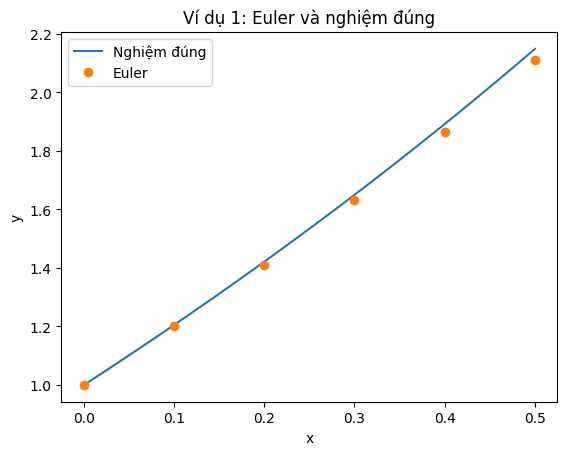

In [3]:

plt.figure()
plt.plot(
    np.linspace(0, 0.5, 200),
    [exact(v) for v in np.linspace(0, 0.5, 200)],
    label="Nghiệm đúng"
)
plt.plot(
    df_euler["x_i"],
    df_euler["y_i"],
    marker="o",
    linestyle="None",
    label="Euler"
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ví dụ 1: Euler và nghiệm đúng")
plt.legend()
plt.show()



## Ví dụ 2 — Euler cho mô hình làm lạnh phi tuyến

Bài toán:

\[
\begin{cases}
T'
=
0.002(30-T)^2-0.5,
\quad t\in[0,0.2],\\
T(0)=20.
\end{cases}
\]

Dùng Euler với

\[
h=0.05.
\]

Nghiệm đúng được cho trong chương:

\[
T(t)
=
30
-
5\sqrt{10}
\tanh
\left(
\frac{t}{10\sqrt{10}}
+
\operatorname{arctanh}
\frac{2}{\sqrt{10}}
\right).
\]


In [4]:

df_cool_euler = euler(
    cooling_rhs,
    0.0,
    20.0,
    0.05,
    4
)

df_cool_euler = attach_exact_solution(
    df_cool_euler,
    cooling_exact,
    approx_col="y_i",
    x_col="x_i"
)

df_cool_euler.rename(
    columns={
        "x_i": "t_i",
        "y_i": "T_i",
        "y_exact": "T_exact",
        "abs_error": "abs_error"
    }
)


,i,t_i,T_i,T_exact,abs_error
0,0,0.00,20.000000000000,20.000000000000,0.000000000000
1,1,0.05,19.985000000000,19.985014997490,0.000014997490
2,2,0.10,19.970030022500,19.970059979840,0.000029957340
3,3,0.15,19.955090052275,19.955134931692,0.000044879417
4,4,0.20,19.940180073861,19.940239837450,0.000059763589



## Ví dụ 3 — Euler cải tiến cho \(y'=x(x^2+e^y+2)\)

Giải bài toán

\[
\begin{cases}
y'=x(x^2+e^y+2),
\quad x\in[0.5,0.7],\\
y(0.5)=1
\end{cases}
\]

bằng Euler cải tiến với

\[
h=0.1.
\]

Ở mỗi bước:

\[
\widetilde y_{i+1}
=
y_i+h f(x_i;y_i),
\]

\[
y_{i+1}
=
y_i
+
\frac h2
\left[
f(x_i;y_i)
+
f(x_{i+1};\widetilde y_{i+1})
\right].
\]


In [5]:

f = lambda x, y: x*(x**2 + math.exp(y) + 2)

df_imp1 = improved_euler(
    f,
    0.5,
    1.0,
    0.1,
    2
)

df_imp1


,i,x_i,y_i,y_predict
0,0,0.5,1.000000000000,NaN
1,1,0.6,1.299551405099,1.248414091423
2,2,0.7,1.751829767363,1.661210465639



## Ví dụ 4 — Euler cải tiến cho \(y'=y-x+1\)

Giải

\[
\begin{cases}
y'=y-x+1,
\quad x\in[0,0.5],\\
y(0)=1
\end{cases}
\]

bằng Euler cải tiến với

\[
h=0.1.
\]

Nghiệm đúng:

\[
y(x)=e^x+x.
\]


In [6]:

f = lambda x, y: y - x + 1
exact = lambda x: math.exp(x) + x

df_imp2 = improved_euler(
    f,
    0.0,
    1.0,
    0.1,
    5
)

df_imp2 = attach_exact_solution(
    df_imp2,
    exact
)

df_imp2


,i,x_i,y_i,y_predict,y_exact,abs_error
0,0,0.0,1.000000000000,NaN,1.000000000000,0.000000000000
1,1,0.1,1.205000000000,1.200000000000,1.205170918076,0.000170918076
2,2,0.2,1.421025000000,1.415500000000,1.421402758160,0.000377758160
3,3,0.3,1.649232625000,1.643127500000,1.649858807576,0.000626182576
4,4,0.4,1.890902050625,1.884155887500,1.891824697641,0.000922647016
5,5,0.5,2.147446765941,2.139992255688,2.148721270700,0.001274504760



## Ví dụ 5 — Euler cải tiến cho mô hình làm lạnh phi tuyến

Trở lại bài toán

\[
\begin{cases}
T'
=
0.002(30-T)^2-0.5,
\quad t\in[0,0.2],\\
T(0)=20.
\end{cases}
\]

Dùng Euler cải tiến với

\[
h=0.05.
\]

Notebook so sánh các giá trị gần đúng với nghiệm đúng đã cho trong chương.


In [7]:

df_cool_imp = improved_euler(
    cooling_rhs,
    0.0,
    20.0,
    0.05,
    4
)

df_cool_imp = attach_exact_solution(
    df_cool_imp,
    cooling_exact,
    approx_col="y_i",
    x_col="x_i"
)

df_cool_imp.rename(
    columns={
        "x_i": "t_i",
        "y_i": "T_i",
        "y_predict": "T_predict",
        "y_exact": "T_exact"
    }
)


,i,t_i,T_i,T_predict,T_exact,abs_error
0,0,0.00,20.000000000000,NaN,20.000000000000,0.000000000000
1,1,0.05,19.985015011250,19.985000000000,19.985014997490,0.000000013760
2,2,0.10,19.970060007328,19.970045003682,19.970059979840,0.000000027487
3,3,0.15,19.955134972874,19.955119976953,19.955134931692,0.000000041182
4,4,0.20,19.940239892294,19.940224904216,19.940239837450,0.000000054844



## Ví dụ 6 — Runge--Kutta bậc bốn

Giải bài toán

\[
\begin{cases}
y'
=
y(x+1)+2x^2,
\quad x\in[0.5,0.7],\\
y(0.5)=1
\end{cases}
\]

bằng Runge--Kutta bậc bốn với

\[
h=0.1.
\]

Ở mỗi bước, notebook ghi lại đầy đủ

\[
k_1,\quad k_2,\quad k_3,\quad k_4
\]

và giá trị \(y_{i+1}\).


In [8]:

f = lambda x, y: y*(x+1) + 2*x**2

df_rk1 = rk4(
    f,
    0.5,
    1.0,
    0.1,
    2
)

df_rk1


,i,x_i,y_i,k1,k2,k3,k4
0,0,0.5,1.000000000000,NaN,NaN,NaN,NaN
1,1,0.6,1.233024900000,0.200000000,0.23100000000,0.233402500000,0.269344400000
2,2,0.7,1.545959092098,0.269283984,0.31016503718,0.313537724067,0.360915646091



## Ví dụ 7 — Runge--Kutta bậc bốn cho \(y'=y-x+1\)

Giải

\[
\begin{cases}
y'=y-x+1,
\quad x\in[0,0.5],\\
y(0)=1
\end{cases}
\]

bằng Runge--Kutta bậc bốn với

\[
h=0.1.
\]

Nghiệm đúng:

\[
y(x)=e^x+x.
\]

Ví dụ này trong chương được dùng để so sánh sai số giữa:
- Euler;
- Euler cải tiến;
- Runge--Kutta bậc bốn.


In [9]:

f = lambda x, y: y - x + 1
exact = lambda x: math.exp(x) + x

df_rk2 = rk4(
    f,
    0.0,
    1.0,
    0.1,
    5
)

df_rk2 = attach_exact_solution(
    df_rk2,
    exact
)

df_rk2


,i,x_i,y_i,k1,k2,k3,k4,y_exact,abs_error
0,0,0.0,1.000000000000,NaN,NaN,NaN,NaN,1.000000000000,0.000000000000
1,1,0.1,1.205170833333,0.200000000000,0.205000000000,0.205250000000,0.210525000000,1.205170918076,0.000000084742
2,2,0.2,1.421402570851,0.210517083333,0.216042937500,0.216319230208,0.222149006354,1.421402758160,0.000000187309
3,3,0.3,1.649858497063,0.222140257085,0.228247269939,0.228552620582,0.234995519143,1.649858807576,0.000000310513
4,4,0.4,1.891824240081,0.234985849706,0.241735142192,0.242072606816,0.249193110388,1.891824697641,0.000000457561
5,5,0.5,2.148720638597,0.249182424008,0.256641545208,0.257014501268,0.264883874135,2.148721270700,0.000000632103


,x,Euler,Euler cải tiến,RK4
0,0.1,0.005170918076,0.000170918076,0.000000084742
1,0.2,0.011402758160,0.000377758160,0.000000187309
2,0.3,0.018858807576,0.000626182576,0.000000310513
3,0.4,0.027724697641,0.000922647016,0.000000457561
4,0.5,0.038211270700,0.001274504760,0.000000632103


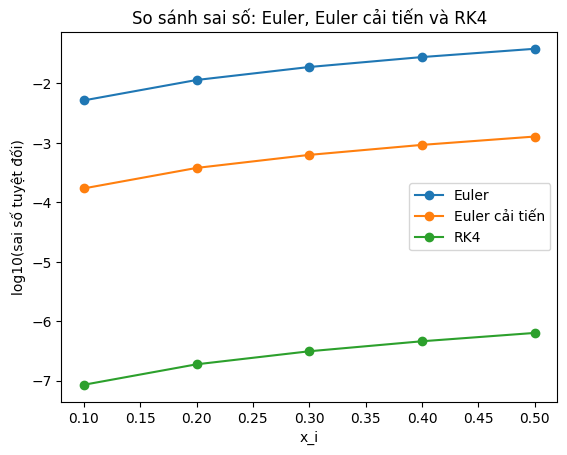

In [10]:

# So sánh log10 sai số của ba phương pháp ở các nút x=0.1,...,0.5

compare = pd.DataFrame({
    "x": df_euler["x_i"][1:].to_numpy(),
    "Euler": df_euler["abs_error"][1:].to_numpy(),
    "Euler cải tiến": df_imp2["abs_error"][1:].to_numpy(),
    "RK4": df_rk2["abs_error"][1:].to_numpy(),
})

display(compare)

plt.figure()

for col in ["Euler", "Euler cải tiến", "RK4"]:
    plt.plot(
        compare["x"],
        np.log10(compare[col]),
        marker="o",
        label=col
    )

plt.xlabel("x_i")
plt.ylabel("log10(sai số tuyệt đối)")
plt.title("So sánh sai số: Euler, Euler cải tiến và RK4")
plt.legend()
plt.show()



## Ví dụ 8 — Runge--Kutta cho mô hình làm lạnh phi tuyến

Trở lại bài toán

\[
\begin{cases}
T'
=
0.002(30-T)^2-0.5,
\quad t\in[0,0.2],\\
T(0)=20.
\end{cases}
\]

Dùng Runge--Kutta bậc bốn với

\[
h=0.05.
\]

Notebook đồng thời so sánh sai số của Euler, Euler cải tiến và RK4.


In [11]:

df_cool_rk = rk4(
    cooling_rhs,
    0.0,
    20.0,
    0.05,
    4
)

df_cool_rk = attach_exact_solution(
    df_cool_rk,
    cooling_exact,
    approx_col="y_i",
    x_col="x_i"
)

df_cool_rk.rename(
    columns={
        "x_i": "t_i",
        "y_i": "T_i",
        "y_exact": "T_exact"
    }
)


,i,t_i,T_i,k1,k2,k3,k4,T_exact,abs_error
0,0,0.00,20.000000000000,NaN,NaN,NaN,NaN,20.000000000000,0.000000000000e+00
1,1,0.05,19.985014997490,-0.015000000000,-0.014984994375,-0.014985009392,-0.014970007526,19.985014997490,3.552713678801e-15
2,2,0.10,19.970059979840,-0.014970007540,-0.014955009497,-0.014955024529,-0.014940030305,19.970059979840,1.065814103640e-14
3,3,0.15,19.955134931692,-0.014940030319,-0.014925039978,-0.014925055025,-0.014910068562,19.955134931692,1.776356839400e-14
4,4,0.20,19.940239837450,-0.014910068576,-0.014895086055,-0.014895101116,-0.014880122533,19.940239837450,1.776356839400e-14


,t,Euler,Euler cải tiến,RK4
0,0.05,0.000014997490,0.000000013760,3.552713678801e-15
1,0.10,0.000029957340,0.000000027487,1.065814103640e-14
2,0.15,0.000044879417,0.000000041182,1.776356839400e-14
3,0.20,0.000059763589,0.000000054844,1.776356839400e-14


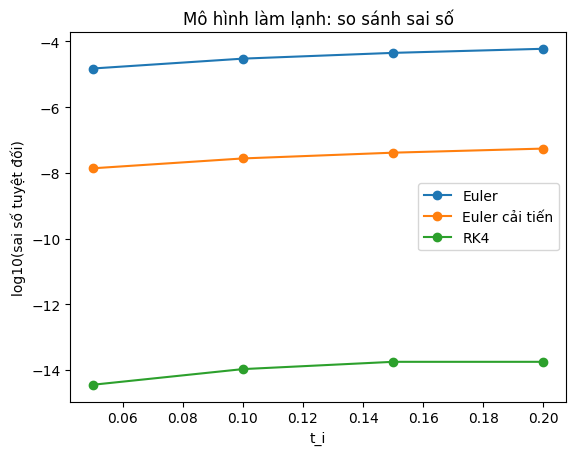

In [12]:

cool_compare = pd.DataFrame({
    "t": df_cool_euler["x_i"][1:].to_numpy(),
    "Euler": df_cool_euler["abs_error"][1:].to_numpy(),
    "Euler cải tiến": df_cool_imp["abs_error"][1:].to_numpy(),
    "RK4": df_cool_rk["abs_error"][1:].to_numpy(),
})

display(cool_compare)

plt.figure()

for col in ["Euler", "Euler cải tiến", "RK4"]:
    plt.plot(
        cool_compare["t"],
        np.log10(cool_compare[col]),
        marker="o",
        label=col
    )

plt.xlabel("t_i")
plt.ylabel("log10(sai số tuyệt đối)")
plt.title("Mô hình làm lạnh: so sánh sai số")
plt.legend()
plt.show()



## Ví dụ 9 — Mô hình SIS với \(\mathcal R_0<1\)

Các tham số:

\[
a=0,\quad
b=10,\quad
h=0.1,
\]

\[
\beta=0.6,\quad
\gamma=0.7,
\]

\[
S_0=10,\quad
I_0=90.
\]

Do đó

\[
N=100,
\qquad
\mathcal R_0
=
\frac{0.6}{0.7}
=
\frac67<1.
\]

Hệ:

\[
\begin{cases}
S'
=
-0.006SI+0.7I,\\
I'
=
0.006SI-0.7I.
\end{cases}
\]

Áp dụng Runge--Kutta bậc bốn mở rộng cho hệ đến \(t=10\).


N = 100
R0 = 0.8571428571428572


,i,x_i,S_i,I_i
0,0,0.0,10.000000000000,90.000000000000
1,1,0.1,15.439048348447,84.560951651553
20,20,2.0,62.763409225835,37.236590774165
40,40,4.0,78.301110985254,21.698889014746
60,60,6.0,85.626585016792,14.373414983208
80,80,8.0,89.822989581275,10.177010418725
100,100,10.0,92.498126520037,7.501873479963


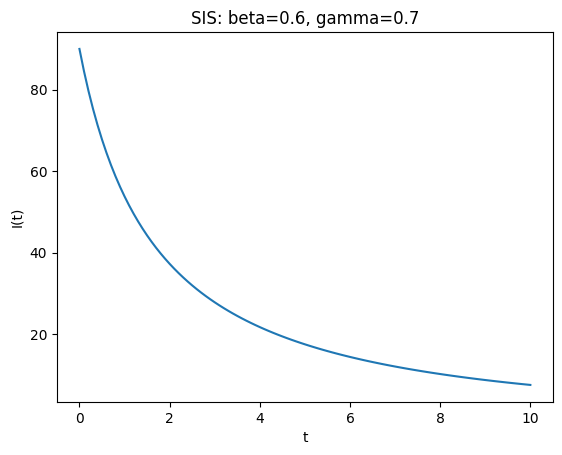

In [13]:

df_sis1, N1, R01 = run_sis(
    beta=0.6,
    gamma=0.7,
    S0=10,
    I0=90,
    h=0.1,
    t_end=10
)

selected_idx = [0, 1, 20, 40, 60, 80, 100]

print("N =", N1)
print("R0 =", R01)

display(df_sis1.iloc[selected_idx])

plt.figure()
plt.plot(df_sis1["x_i"], df_sis1["I_i"])
plt.xlabel("t")
plt.ylabel("I(t)")
plt.title("SIS: beta=0.6, gamma=0.7")
plt.show()



## Ví dụ 10 — Mô hình SIS với \(\mathcal R_0>1\), \(I_0=90\)

Các tham số:

\[
a=0,\quad
b=10,\quad
h=0.1,
\]

\[
\beta=0.8,\quad
\gamma=0.2,
\]

\[
S_0=10,\quad
I_0=90.
\]

Ta có

\[
N=100,
\qquad
\mathcal R_0=4>1.
\]

Mức cân bằng được nêu trong chương:

\[
\left(
1-\frac{\gamma}{\beta}
\right)N
=
75.
\]

Áp dụng RK4 mở rộng cho hệ SIS.


N = 100
R0 = 4.0
I cân bằng theo chương = 75.0


,i,x_i,S_i,I_i
0,0,0.0,10.000000000000,90.000000000000
1,1,0.1,11.036169751661,88.963830248339
20,20,2.0,21.036086808363,78.963913191637
40,40,4.0,23.848616608613,76.151383391387
60,60,6.0,24.656890782563,75.343109217437
80,80,8.0,24.896986797182,75.103013202818
100,100,10.0,24.969002766964,75.030997233036


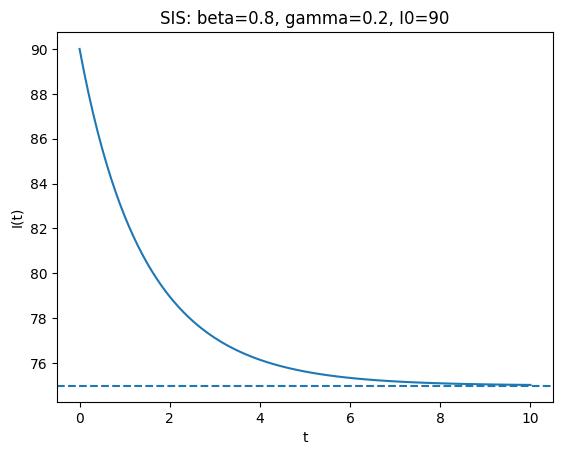

In [14]:

df_sis2, N2, R02 = run_sis(
    beta=0.8,
    gamma=0.2,
    S0=10,
    I0=90,
    h=0.1,
    t_end=10
)

I_star2 = (1 - 0.2/0.8)*N2

print("N =", N2)
print("R0 =", R02)
print("I cân bằng theo chương =", I_star2)

display(df_sis2.iloc[selected_idx])

plt.figure()
plt.plot(df_sis2["x_i"], df_sis2["I_i"])
plt.axhline(I_star2, linestyle="--")
plt.xlabel("t")
plt.ylabel("I(t)")
plt.title("SIS: beta=0.8, gamma=0.2, I0=90")
plt.show()



## Ví dụ 11 — Mô hình SIS với \(\mathcal R_0>1\), \(I_0=10\)

Các tham số:

\[
a=0,\quad
b=10,\quad
h=0.1,
\]

\[
\beta=0.8,\quad
\gamma=0.2,
\]

\[
S_0=90,\quad
I_0=10.
\]

Ta vẫn có

\[
N=100,
\qquad
\mathcal R_0=4>1,
\]

và mức cân bằng được nêu trong chương là

\[
I_\infty=75.
\]

Áp dụng Runge--Kutta bậc bốn mở rộng.


N = 100
R0 = 4.0
I cân bằng theo chương = 75.0


,i,x_i,S_i,I_i
0,0,0.0,90.000000000000,10.000000000000
1,1,0.1,89.468465723166,10.531534276834
20,20,2.0,74.642994074132,25.357005925868
40,40,4.0,52.820299482514,47.179700517486
60,60,6.0,36.311369021989,63.688630978011
80,80,8.0,28.808284405582,71.191715594418
100,100,10.0,26.189231260110,73.810768739890


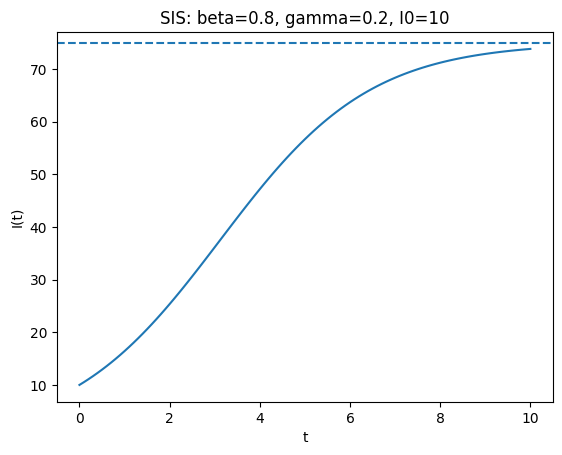

In [15]:

df_sis3, N3, R03 = run_sis(
    beta=0.8,
    gamma=0.2,
    S0=90,
    I0=10,
    h=0.1,
    t_end=10
)

I_star3 = (1 - 0.2/0.8)*N3

print("N =", N3)
print("R0 =", R03)
print("I cân bằng theo chương =", I_star3)

display(df_sis3.iloc[selected_idx])

plt.figure()
plt.plot(df_sis3["x_i"], df_sis3["I_i"])
plt.axhline(I_star3, linestyle="--")
plt.xlabel("t")
plt.ylabel("I(t)")
plt.title("SIS: beta=0.8, gamma=0.2, I0=10")
plt.show()



# Ghi chú

- Các thuật toán được viết theo đúng công thức trình bày trong Chương 7.
- Các ví dụ có nghiệm đúng được bổ sung cột sai số tuyệt đối để đối chiếu với bảng trong giáo trình.
- Các hình so sánh sai số được tái tạo bằng `matplotlib`.
- Ba ví dụ SIS được giải bằng Runge--Kutta bậc bốn mở rộng cho hệ hai phương trình.
- Các ví dụ nằm trong môi trường `comment` và phần bài tập cuối chương không được đưa vào notebook.
